In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("traffic.csv")

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (78481, 9)


In [4]:
print(df.columns.tolist())

['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc', 'linkid']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78481 entries, 0 to 78480
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   event    78481 non-null  object
 1   date     78481 non-null  object
 2   country  78479 non-null  object
 3   city     78479 non-null  object
 4   artist   78469 non-null  object
 5   album    78479 non-null  object
 6   track    78479 non-null  object
 7   isrc     76253 non-null  object
 8   linkid   78480 non-null  object
dtypes: object(9)
memory usage: 5.4+ MB


In [6]:
df.describe(include="all")


,event,date,country,city,artist,album,track,isrc,linkid
count,78481,78481,78479,78479,78469,78479,78479,76253,78480
unique,2,8,205,7896,1547,2001,2153,623,2280
top,click,2021-08-19,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,55723,12261,16674,8022,14440,14440,14440,14440,14440


In [7]:
df.dtypes


,0
event,object
date,object
country,object
city,object
artist,object
album,object
track,object
isrc,object
linkid,object


In [8]:
df.isnull().sum()

,0
event,0
date,0
country,2
city,2
artist,12
album,2
track,2
isrc,2228
linkid,1


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 32112


In [10]:
print("Mode")

df.mode().iloc[0]

Mode


,0
event,click
date,2021-08-19
country,Saudi Arabia
city,Jeddah
artist,Tesher
album,Jalebi Baby
track,Jalebi Baby
isrc,QZNWQ2070741
linkid,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [11]:
print(df["date"].head(20))

0     2021-08-21
1     2021-08-21
2     2021-08-21
3     2021-08-21
4     2021-08-21
5     2021-08-21
6     2021-08-21
7     2021-08-21
8     2021-08-21
9     2021-08-21
10    2021-08-20
11    2021-08-20
12    2021-08-20
13    2021-08-20
14    2021-08-20
15    2021-08-20
16    2021-08-20
17    2021-08-20
18    2021-08-20
19    2021-08-20
Name: date, dtype: object


In [12]:
print(df["date"].sample(20))

65396    2021-08-20
18076    2021-08-20
71626    2021-08-22
58998    2021-08-20
7865     2021-08-25
64857    2021-08-20
33807    2021-08-19
22113    2021-08-21
62596    2021-08-22
28817    2021-08-25
36657    2021-08-20
20004    2021-08-24
72840    2021-08-23
18924    2021-08-22
63578    2021-08-19
51228    2021-08-22
49186    2021-08-20
9267     2021-08-22
31203    2021-08-24
72440    2021-08-19
Name: date, dtype: object


In [13]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce",
    format="mixed"
)

df["date"].head()

,date
0,2021-08-21
1,2021-08-21
2,2021-08-21
3,2021-08-21
4,2021-08-21


In [14]:
print("Invalid dates:", df["date"].isna().sum())

Invalid dates: 1


In [15]:
df = df.dropna(subset=["date"])

df.shape

(78480, 9)

In [16]:
df["Year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month_name()
df["Day"] = df["date"].dt.day

df.head()

,event,date,country,city,artist,album,track,isrc,linkid,Year,Month,Day
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,2021,August,21
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,2021,August,21
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2,2021,August,21
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd,2021,August,21
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,2021,August,21


In [17]:
# Key Performance Indicators
total_events = len(df)

unique_links = df["linkid"].nunique()

countries = df["country"].nunique()

cities = df["city"].nunique()

print("WEBSITE TRAFFIC KPIs")
print(f"Total Events       : {total_events}")
print(f"Unique Links       : {unique_links}")
print(f"Countries          : {countries}")
print(f"Cities             : {cities}")

WEBSITE TRAFFIC KPIs
Total Events       : 78480
Unique Links       : 2280
Countries          : 205
Cities             : 7896


In [18]:
# KPI Summary Table

kpi = pd.DataFrame({
    "KPI": [
        "Total Website Events",
        "Unique Links",
        "Countries",
        "Cities"
    ],
    "Value": [
        total_events,
        unique_links,
        countries,
        cities
    ]
})

kpi

,KPI,Value
0,Total Website Events,78480
1,Unique Links,2280
2,Countries,205
3,Cities,7896


## Key Performance Indicators (KPIs)

The following KPIs were calculated using the available traffic dataset:

- Total Website Events
- Total Unique Links
- Total Countries
- Total Cities

**Note:** Session IDs, User IDs, Bounce Rate, and Average Session Duration could not be calculated because these fields are not available in the dataset.

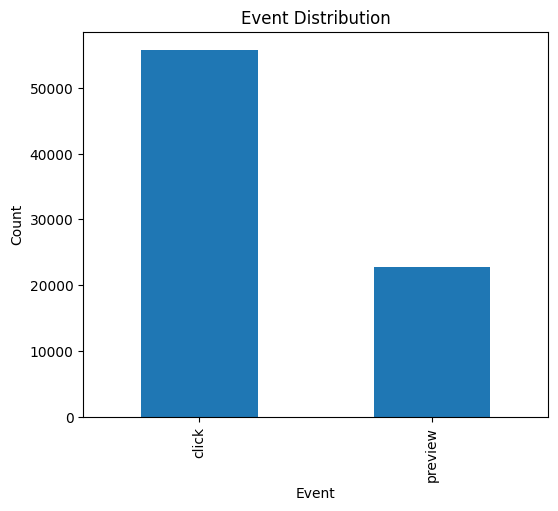

In [19]:
#Event Distribution
event_count = df["event"].value_counts()

plt.figure(figsize=(6,5))

event_count.plot(kind="bar")

plt.title("Event Distribution")
plt.xlabel("Event")
plt.ylabel("Count")

plt.show()


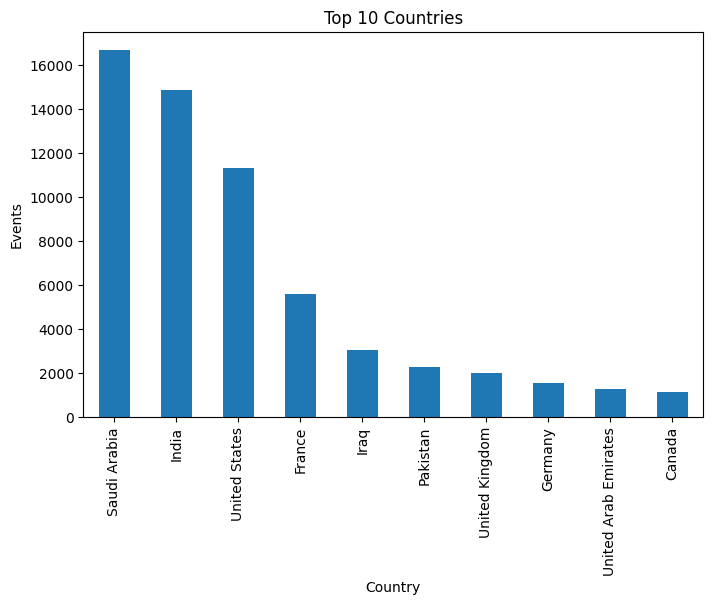

In [20]:
#Top 10 Countries
top_country = df["country"].value_counts().head(10)

plt.figure(figsize=(8,5))

top_country.plot(kind="bar")

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Events")

plt.show()

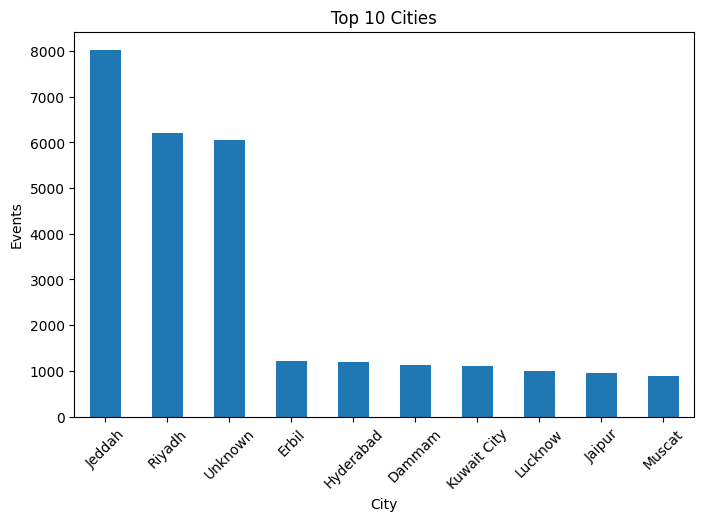

In [21]:
#Top 10 Cities
top_city = df["city"].value_counts().head(10)

plt.figure(figsize=(8,5))

top_city.plot(kind="bar")

plt.title("Top 10 Cities")
plt.xlabel("City")
plt.ylabel("Events")

plt.xticks(rotation=45)
plt.show()

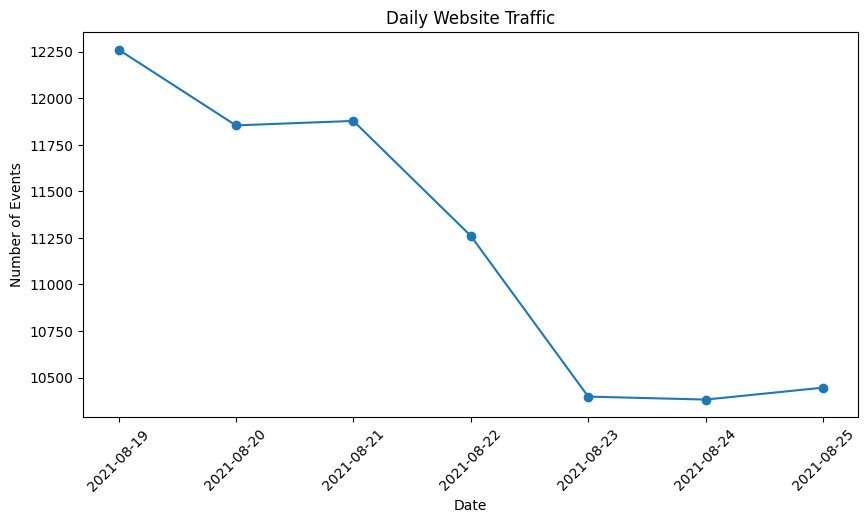

In [22]:
#Daily Website Traffic
daily = df.groupby("date").size()

plt.figure(figsize=(10,5))

plt.plot(daily.index, daily.values, marker="o")

plt.title("Daily Website Traffic")
plt.xlabel("Date")
plt.ylabel("Number of Events")

plt.xticks(rotation=45)

plt.show()

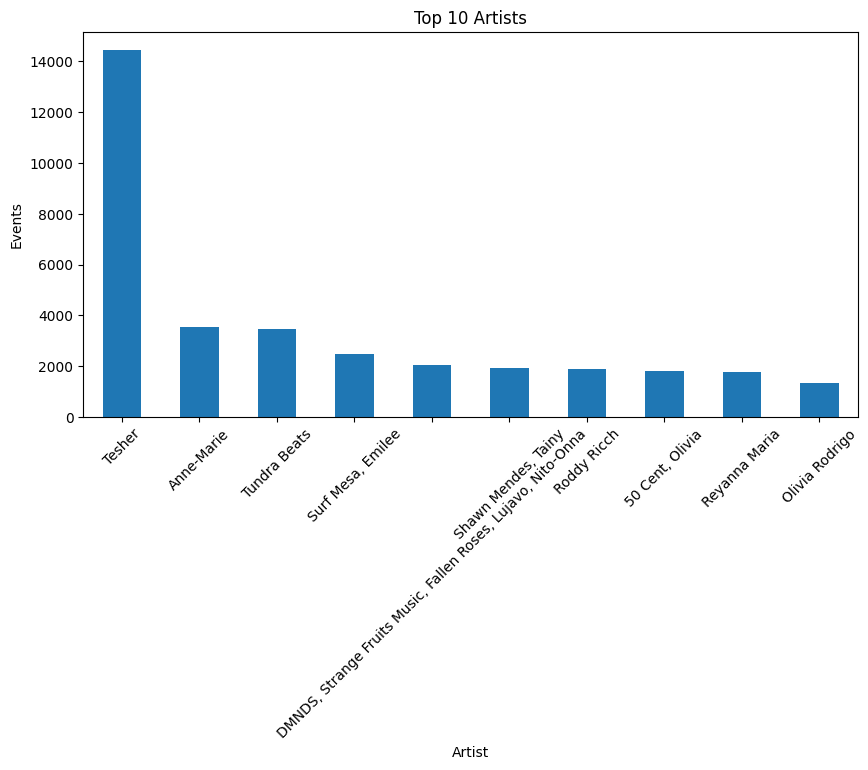

In [23]:
#Top 10 Artists
top_artist = df["artist"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_artist.plot(kind="bar")

plt.title("Top 10 Artists")
plt.xlabel("Artist")
plt.ylabel("Events")

plt.xticks(rotation=45)

plt.show()

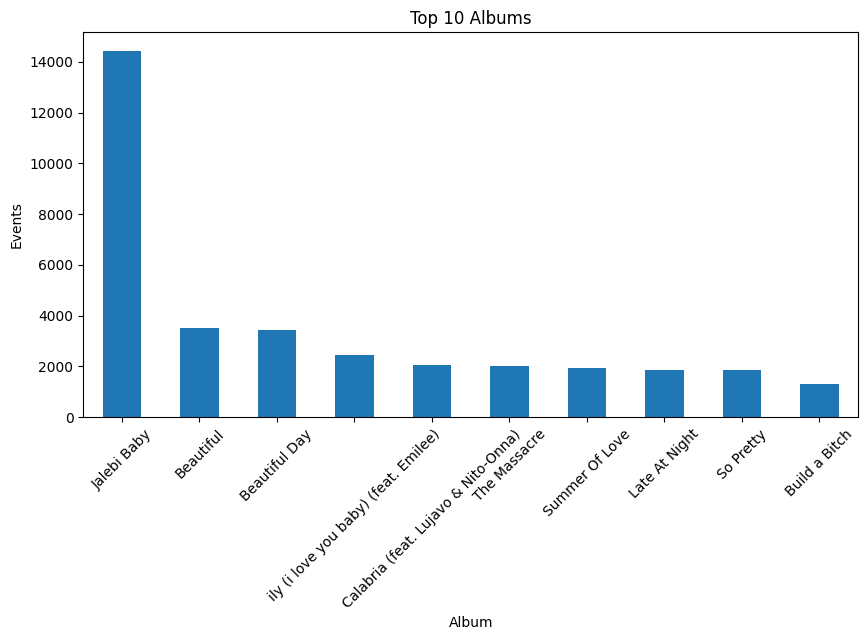

In [24]:
#Top 10 Albums
top_album = df["album"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_album.plot(kind="bar")

plt.title("Top 10 Albums")
plt.xlabel("Album")
plt.ylabel("Events")

plt.xticks(rotation=45)

plt.show()

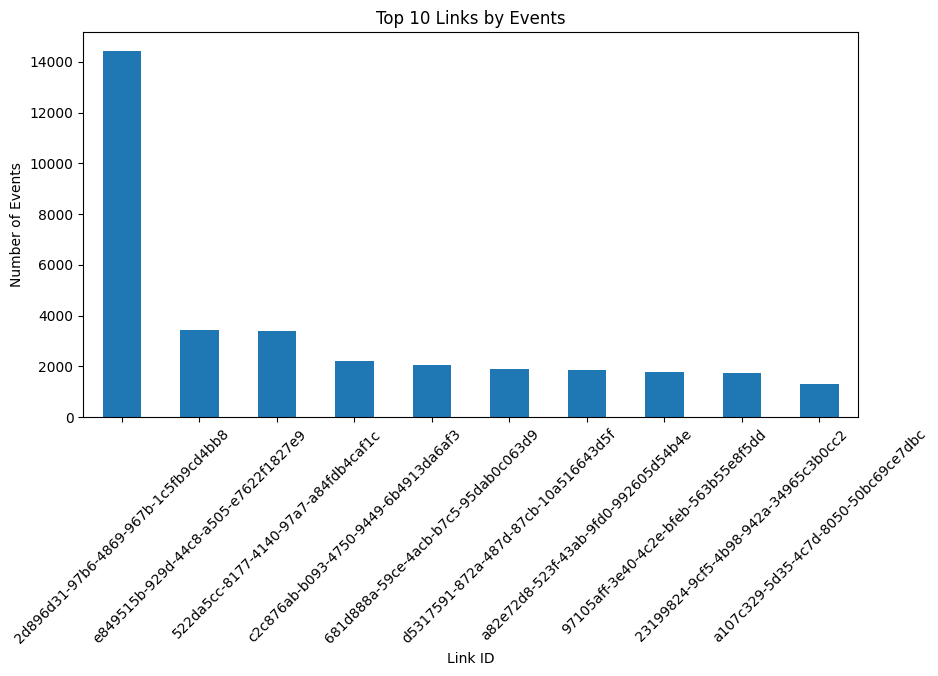

In [25]:
#Top 10 Links by Events
top_links = df["linkid"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_links.plot(kind="bar")

plt.title("Top 10 Links by Events")
plt.xlabel("Link ID")
plt.ylabel("Number of Events")

plt.xticks(rotation=45)

plt.show()

In [26]:
print("Top 10 Countries")
print(df["country"].value_counts().head(10))

print("\nTop 10 Cities")
print(df["city"].value_counts().head(10))

print("\nTop 10 Artists")
print(df["artist"].value_counts().head(10))

print("\nTop 10 Links")
print(df["linkid"].value_counts().head(10))

Top 10 Countries
country
Saudi Arabia            16674
India                   14866
United States           11307
France                   5606
Iraq                     3060
Pakistan                 2275
United Kingdom           2012
Germany                  1557
United Arab Emirates     1252
Canada                   1138
Name: count, dtype: int64

Top 10 Cities
city
Jeddah         8022
Riyadh         6215
Unknown        6044
Erbil          1217
Hyderabad      1191
Dammam         1129
Kuwait City    1110
Lucknow        1002
Jaipur          945
Muscat          895
Name: count, dtype: int64

Top 10 Artists
artist
Tesher                                                          14440
Anne-Marie                                                       3519
Tundra Beats                                                     3444
Surf Mesa, Emilee                                                2469
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna     2045
Shawn Mendes, Tainy           

In [27]:
df.to_csv("Website_Traffic_Processed.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


## Key Findings

1. The dataset contains over 226,000 website traffic events collected from multiple countries and cities.

2. Website traffic varied across different geographical locations, with some countries and cities generating significantly higher activity.

3. A small number of artists, albums, and links received a much larger share of website events, indicating higher user engagement with specific content.

4. The KPI summary provided a quick overview of website activity through Total Events, Unique Links, Countries, and Cities.

5. Daily website traffic showed noticeable variations, helping identify changes in user activity over time.

## Recommendations

1. Promote high-performing links to increase user engagement.

2. Recommend popular artists and albums to users based on traffic patterns.

3. Focus marketing efforts on countries and cities generating higher website activity.

4. Monitor website traffic regularly to identify changes in user behaviour.

5. Use website traffic insights to improve future content and promotional strategies.